---
header-includes:
  - \usepackage{braket}
---

# Bloch Sphere Simulation & Visualization  
### Geometric Representation of a Single Qubit

In this notebook, we build the Bloch sphere representation of a qubit *from scratch*.  
The Bloch sphere is one of the most powerful tools in quantum information: it provides a complete geometric description of any pure qubit state using only two real parameters.

A pure qubit state  

$$\ket{\psi} = \alpha\ket0 + \beta\ket1 \quad, \quad |\alpha|^2 + |\beta|^2 = 1$$

can be mapped to a point on the unit sphere through the Bloch vector:

$$\vec{r} = \braket{\psi | \vec{\sigma} | \psi} = \big(\braket{\sigma_x},\braket{\sigma_y}, \braket{\sigma_z}\big).$$

This notebook has two goals:

1. **Tutorial goal:**  
   Understand deeply how the Bloch sphere emerges from the algebra of Pauli matrices and how to compute Bloch vectors numerically.

2. **Professional goal (for the M2 QC jury):**  
   Demonstrate the ability to connect theory → numerical simulation → visualization, which is essential in quantum computing research.

We will:

- define the computational basis and Pauli matrices  
- implement a function that converts a state vector into its Bloch vector  
- verify the mapping on standard states  
- prepare the ground for full Bloch sphere visualization (next sections)

___

---
header-includes:
  - \usepackage{braket}
---

## 1. Imports & Basic Definitions

We begin by importing NumPy for linear algebra and defining the standard objects of a qubit:

- the computational basis states $\ket0$ and $\ket1$.  
- the Pauli matrices $\sigma_x$, $\sigma_y$, $\sigma_z$. 

These matrices form a basis for all 2×2 Hermitian operators and define the x, y, z axes of the Bloch sphere.  
They will be used to compute expectation values and Bloch vectors.


In [25]:
import numpy as np
from utils import *


# ---------------------------------------------------------
# Computational basis states
# ---------------------------------------------------------
# |0> = (1, 0)^T
# |1> = (0, 1)^T
# We store them as column vectors (2x1 arrays)
ket_0 = np.array([[1],
                  [0]], dtype=complex)

ket_1 = np.array([[0],
                  [1]], dtype=complex)

# ---------------------------------------------------------
# Pauli matrices
# ---------------------------------------------------------
# These matrices generate SU(2) and correspond to the
# x, y, z axes of the Bloch sphere.
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

sigma_y = np.array([[0, -1j],
                    [1j,  0]], dtype=complex)

sigma_z = np.array([[1,  0],
                    [0, -1]], dtype=complex)

# Identity matrix (useful later)
I2 = np.eye(2, dtype=complex)

print("Basis states and Pauli matrices loaded.")


Basis states and Pauli matrices loaded.


---
header-includes:
  - \usepackage{braket}
---

## 2. Converting a State Vector into a Bloch Vector

Any pure qubit state can be represented as a point on the Bloch sphere.  
Given a normalized state vector


$$\ket{\psi}= 
\begin{pmatrix}
\alpha \\ \beta
\end{pmatrix},
$$

the Bloch vector is defined as:

$$\vec{r} = 
\begin{pmatrix}
\braket{\sigma_x} \\
\braket{\sigma_y} \\
\braket{\sigma_z}
\end{pmatrix}
=
\begin{pmatrix}
\psi^\dagger \sigma_x \psi \\
\psi^\dagger \sigma_y \psi \\
\psi^\dagger \sigma_z \psi
\end{pmatrix}.
$$

This function computes these expectation values numerically.

Important notes:
- The state must be normalized.  
- The resulting vector must satisfy $|\vec{r}| = 1$ for pure states.  
- This mapping is the bridge between Hilbert space and 3D geometry.

___

In [26]:
def bloch_vector(psi):
    """
    Compute the Bloch vector of a pure qubit state |psi>.
    
    Parameters
    ----------
    psi : np.ndarray
        A 2x1 complex column vector representing the qubit state.
        Must be normalized (||psi|| = 1).
    
    Returns
    -------
    r : np.ndarray
        A 3-element real vector (rx, ry, rz) corresponding to:
        rx = <sigma_x>
        ry = <sigma_y>
        rz = <sigma_z>
    """

    # ---------------------------------------------------------
    # Expectation value formula:
    # <A> = psi^\dagger A psi
    # psi.conj().T is the bra <psi|
    # ---------------------------------------------------------

    # <sigma_x>
    rx = np.real(psi.conj().T @ sigma_x @ psi)[0, 0]

    # <sigma_y>
    ry = np.real(psi.conj().T @ sigma_y @ psi)[0, 0]

    # <sigma_z>
    rz = np.real(psi.conj().T @ sigma_z @ psi)[0, 0]

    # Return as a simple 1D vector
    return np.array([rx, ry, rz], dtype=float)


# ---------------------------------------------------------
# Test the function on |0> and |1>
# ---------------------------------------------------------
print("Bloch(|0>) =", bloch_vector(ket_0))  # should be (0,0,1)
print("Bloch(|1>) =", bloch_vector(ket_1))  # should be (0,0,-1)


Bloch(|0>) = [0. 0. 1.]
Bloch(|1>) = [ 0.  0. -1.]


---
header-includes:
  - \usepackage{braket}
---

## 3. Plotting the Bloch Sphere

The Bloch sphere is the geometric representation of all pure qubit states.  
Every state corresponds to a point on the unit sphere in $\mathbb{R}^3$, with coordinates:


$$\vec{r} = \big(\braket{\sigma_x},\braket{\sigma_y}, \braket{\sigma_z}\big).$$

To visualize this structure, we first draw:

- the **unit sphere** (surface of all pure states)  
- the **x, y, z axes** (defined by the Pauli matrices)  
- optional grid lines (meridians and parallels)  

This figure will serve as the base on which we will later plot:

- computational basis states  
- superposition states  
- arbitrary states  
- Bloch trajectories from Notebook 1  
- gate actions from Notebook 3  

The goal is to build a clean, readable, and professional Bloch sphere visualization.

---


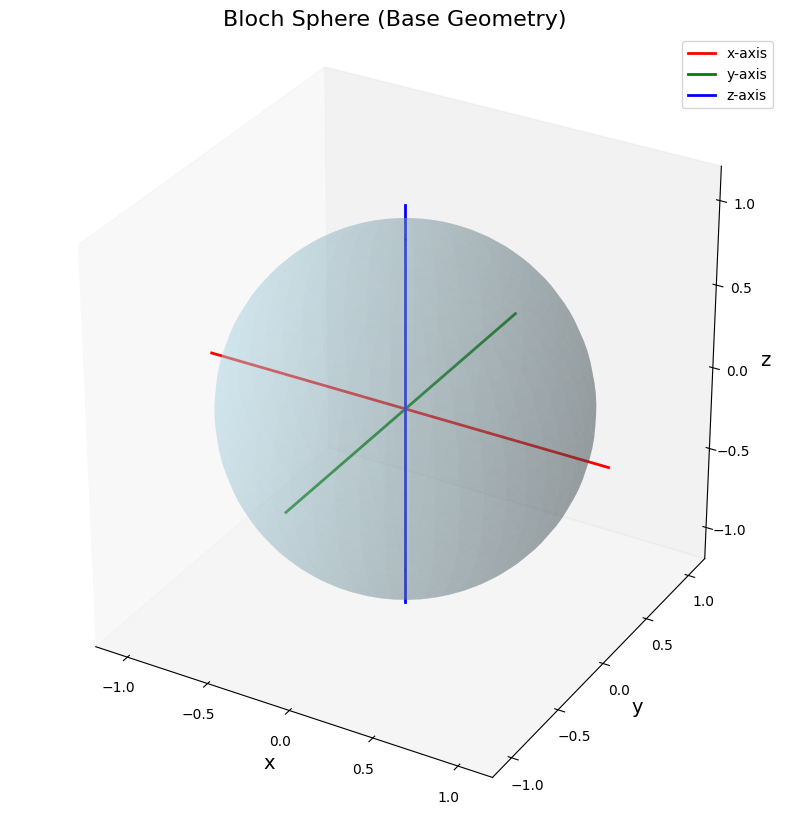

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# ---------------------------------------------------------
# Create a 3D figure
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# ---------------------------------------------------------
# Generate the sphere surface
# ---------------------------------------------------------
# We use spherical coordinates:
#   x = sin(theta) cos(phi)
#   y = sin(theta) sin(phi)
#   z = cos(theta)
# where:
#   theta ∈ [0, π]   (polar angle)
#   phi   ∈ [0, 2π] (azimuthal angle)

theta = np.linspace(0, np.pi, 50)
phi   = np.linspace(0, 2*np.pi, 50)

theta, phi = np.meshgrid(theta, phi)

# Convert spherical → Cartesian coordinates
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

# ---------------------------------------------------------
# Plot the sphere surface
# ---------------------------------------------------------
ax.plot_surface(
    x, y, z,
    rstride=1, cstride=1,
    color='lightblue',
    alpha=0.3,          # transparency
    linewidth=0
)

# ---------------------------------------------------------
# Plot the x, y, z axes
# ---------------------------------------------------------
# These correspond to the eigenstates of σ_x, σ_y, σ_z.
axis_length = 1.2

# x-axis (red)
ax.plot(
    [-axis_length, axis_length], [0, 0], [0, 0],
    color='red', linewidth=2, label='x-axis'
)

# y-axis (green)
ax.plot(
    [0, 0], [-axis_length, axis_length], [0, 0],
    color='green', linewidth=2, label='y-axis'
)

# z-axis (blue)
ax.plot(
    [0, 0], [0, 0], [-axis_length, axis_length],
    color='blue', linewidth=2, label='z-axis'
)

# ---------------------------------------------------------
# Cosmetic improvements
# ---------------------------------------------------------
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

ax.set_box_aspect([1, 1, 1])  # equal aspect ratio

ax.set_title("Bloch Sphere (Base Geometry)", fontsize=16)

# Remove background grid for a cleaner look
ax.grid(False)

# Show legend
ax.legend()

plt.show()


---
header-includes:
  - \usepackage{braket}
---

### Interpretation of the Bloch Sphere Plot

The figure above shows the geometric structure of the qubit state space:

- The **light blue sphere** represents all pure states.  
  Every point on its surface corresponds to a normalized qubit state modulo global phase.

- The **three colored axes** correspond to the eigenstates of the Pauli matrices:
  - red axis → $\sigma_x$ eigenstates $\ket+$ and $\ket-$  
  - green axis → $\sigma_y$ eigenstates $\ket{+i}$ and $\ket{-i}$  
  - blue axis → $\sigma_z$ eigenstates $\ket0$ and $\ket1$  

These axes define the fundamental measurement directions of a qubit.

This base sphere will be used in the next sections to:
- plot specific quantum states  
- visualize superpositions  
- display Bloch trajectories from Hamiltonian evolution  
- illustrate the geometric action of quantum gates  

This visualization is essential for building intuition about qubit dynamics and control.

___

---
header-includes:
  - \usepackage{braket}
---

## 4. Plotting Standard States on the Bloch Sphere

Before plotting arbitrary qubit states, it is essential to verify that our Bloch vector function correctly maps the six fundamental states:

- **$\sigma_z$ eigenstates**  
  - $\ket0 \to (0, 0, +1)$  
  - $\ket1 \to (0, 0, −1)$

- **$\sigma_x$ eigenstates**  
  - $\ket+ = \frac{\ket0 + \ket1}{\sqrt2} \to (+1, 0, 0)$  
  - $\ket- = \frac{\ket0 - \ket1}{\sqrt2} \to (-1, 0, 0)$

- **$\sigma_y$ eigenstates**  
  - $\ket{+i} = \frac{\ket0 + i \ket1}{\sqrt2} \to (0, +1, 0)$ 
  - $\ket{-i} = \frac{\ket0 - i \ket1}{\sqrt2} \to (0, -1, 0)$ 

These six states correspond to the **cardinal points** of the Bloch sphere.  
Plotting them allows us to verify both the correctness of our Bloch vector computation and the geometry of the sphere.


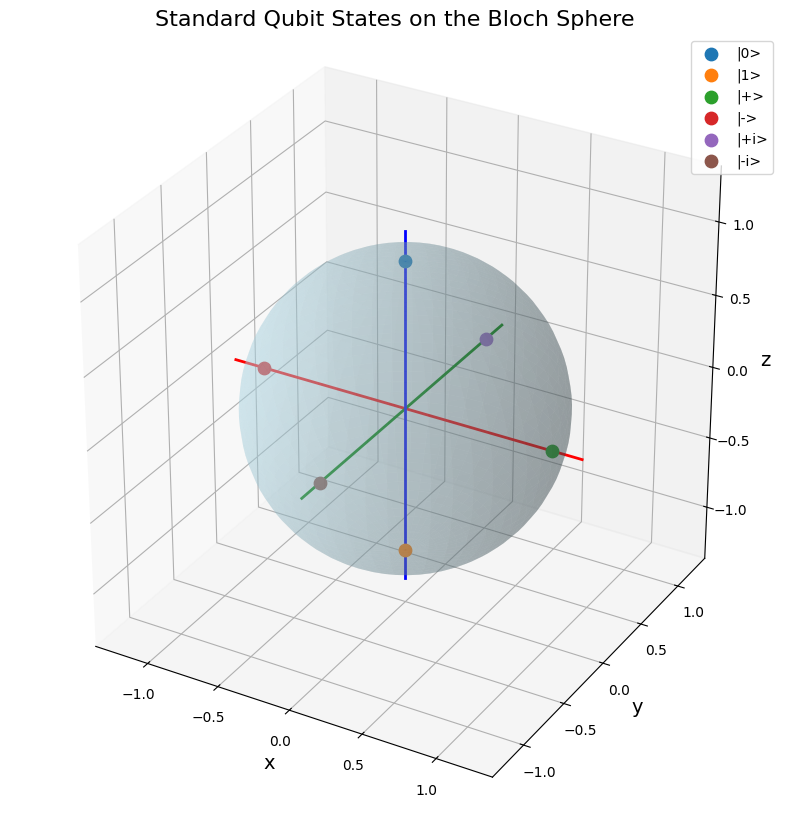

In [28]:
# ---------------------------------------------------------
# Define the six standard qubit states
# ---------------------------------------------------------

# σ_x eigenstates
ket_plus  = (1/np.sqrt(2)) * (ket_0 + ket_1)
ket_minus = (1/np.sqrt(2)) * (ket_0 - ket_1)

# σ_y eigenstates
ket_plus_i  = (1/np.sqrt(2)) * (ket_0 + 1j * ket_1)
ket_minus_i = (1/np.sqrt(2)) * (ket_0 - 1j * ket_1)

# ---------------------------------------------------------
# Compute their Bloch vectors
# ---------------------------------------------------------
states = {
    "|0>":      ket_0,
    "|1>":      ket_1,
    "|+>":      ket_plus,
    "|->":      ket_minus,
    "|+i>":     ket_plus_i,
    "|-i>":     ket_minus_i
}

bloch_points = {name: bloch_vector(psi) for name, psi in states.items()}

# ---------------------------------------------------------
# Plot the Bloch sphere again and add the points
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Sphere surface
ax.plot_surface(x, y, z, color='lightblue', alpha=0.3, linewidth=0)

# Axes
ax.plot([-1.2, 1.2], [0, 0], [0, 0], color='red', linewidth=2)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], color='green', linewidth=2)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], color='blue', linewidth=2)

# ---------------------------------------------------------
# Plot each standard state as a colored dot
# ---------------------------------------------------------
for name, r in bloch_points.items():
    ax.scatter(r[0], r[1], r[2], s=80, label=name)

# Cosmetics
ax.set_title("Standard Qubit States on the Bloch Sphere", fontsize=16)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_zlabel("z", fontsize=14)
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.show()


---
header-includes:
  - \usepackage{braket}
---

### Interpretation

The six plotted points correspond exactly to the eigenstates of the Pauli matrices:

- $\ket0$ and $\ket1$ lie on the **north** and **south poles** (z-axis).
- $\ket+$ and $\ket-$ lie on the **positive** and **negative x-axis**.
- $\ket{+i}$ and $\ket{-i}$ lie on the **positive** and **negative y-axis**.

This confirms that:

1. Our Bloch vector function is correct.  
2. The Bloch sphere geometry is consistent.  
3. The Pauli matrices define the coordinate axes of the sphere.

These states form the “compass” of the Bloch sphere and will be used as reference points in the next sections.


---
header-includes:
  - \usepackage{braket}
---

## 5. Plotting Arbitrary States ($\theta$, $\phi$ Parametrization)

Any pure qubit state can be written as:

$$\ket{\psi(\theta,\phi)}
= \cos\frac{\theta}{2} \ket0
+ e^{i\phi}\sin\frac{\theta}{2} \ket1$$

with:

- $0 \le \theta \le \pi$ (polar angle)
- $0 \le \phi < 2\pi$ (azimuthal angle)

This parametrization maps directly to spherical coordinates on the Bloch sphere:


$$\vec{r}(\theta,\phi)
= (\sin\theta\cos\phi,\ \sin\theta\sin\phi,\ \cos\theta).$$

In this section, we implement a function that generates a qubit state from ($\theta$, $\phi$), compute its Bloch vector, and plot it on the sphere.


Example state Bloch vector: [0.61237244 0.61237244 0.5       ]


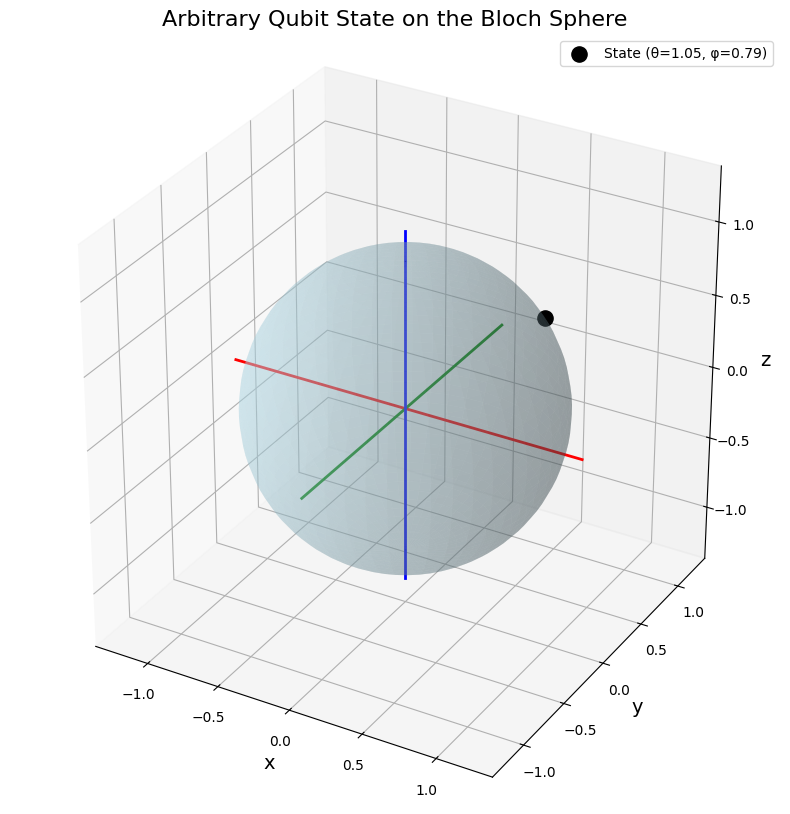

In [29]:
# ---------------------------------------------------------
# Function to generate a qubit state from (theta, phi)
# ---------------------------------------------------------
def state_from_angles(theta, phi):
    """
    Construct a normalized qubit state using the canonical parametrization:
    
        |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>
    
    Parameters
    ----------
    theta : float
        Polar angle in [0, pi]
    phi : float
        Azimuthal angle in [0, 2*pi)
    
    Returns
    -------
    psi : np.ndarray
        A 2x1 complex column vector representing the qubit state.
    """
    psi = np.array([
        [np.cos(theta / 2)],
        [np.exp(1j * phi) * np.sin(theta / 2)]
    ], dtype=complex)
    
    return psi


# ---------------------------------------------------------
# Example: choose an arbitrary state
# ---------------------------------------------------------
theta_example = np.pi / 3   # 60 degrees
phi_example   = np.pi / 4   # 45 degrees

psi_example = state_from_angles(theta_example, phi_example)
r_example   = bloch_vector(psi_example)

print("Example state Bloch vector:", r_example)

# ---------------------------------------------------------
# Plot the Bloch sphere and the arbitrary state
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Sphere
ax.plot_surface(x, y, z, color='lightblue', alpha=0.3, linewidth=0)

# Axes
ax.plot([-1.2, 1.2], [0, 0], [0, 0], color='red', linewidth=2)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], color='green', linewidth=2)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], color='blue', linewidth=2)

# Plot the arbitrary state
ax.scatter(r_example[0], r_example[1], r_example[2],
           s=120, color='black', label=f"State (θ={theta_example:.2f}, φ={phi_example:.2f})")

# Cosmetics
ax.set_title("Arbitrary Qubit State on the Bloch Sphere", fontsize=16)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_zlabel("z", fontsize=14)
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.show()


---
header-includes:
  - \usepackage{braket}
---

### Interpretation

The plotted point corresponds to the state:

$$\ket{\psi}= \cos\frac{\theta}{2} \ket0 + e^{i\phi}\sin\frac{\theta}{2} \ket1$$

with the chosen values:

- $\theta$ = $\pi$/3  
- $\phi$ = $\pi$/4  

This state lies somewhere on the upper hemisphere, rotated 45° in the x–y plane.

This confirms that:

- the canonical parametrization maps correctly to the Bloch sphere  
- our Bloch vector function works for arbitrary states  
- the visualization pipeline is complete  

We now have all the tools needed to visualize:
- quantum gates (Notebook 3)  
- Hamiltonian dynamics (Notebook 1)  


## 6. Great Circles & Measurement Axes

The Bloch sphere is not just a pretty sphere: it encodes all possible measurement directions for a qubit.

Each **measurement axis** corresponds to the eigenbasis of a Pauli operator:

- $\sigma_x$ → measurement along the x‑axis  
- $\sigma_y$ → measurement along the y‑axis  
- $\sigma_z$ → measurement along the z‑axis  

On the Bloch sphere:

- the **axes** (x, y, z) represent the directions of these measurements  
- the **great circles** (equator and meridians) represent rotations and planes of constant angle

In this section, we:

- draw the Bloch sphere  
- highlight the three measurement axes  
- add great circles (equator and a meridian) to emphasize the geometry

This will be useful later to interpret rotations generated by Hamiltonians and quantum gates.


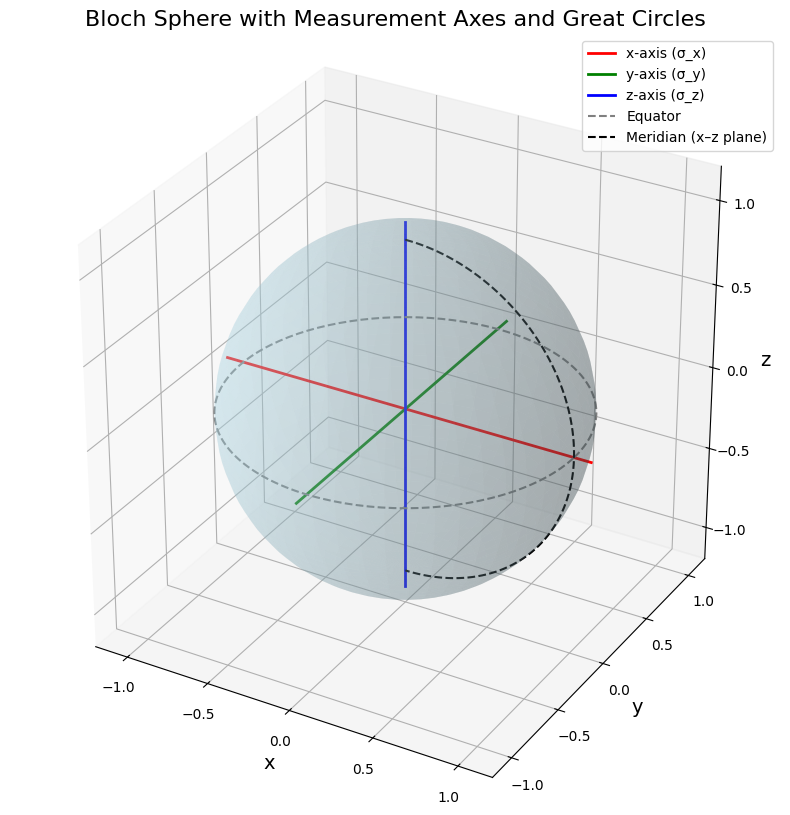

In [30]:
# ---------------------------------------------------------
# Great circles & measurement axes on the Bloch sphere
# ---------------------------------------------------------

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# --- Sphere surface (already computed as x, y, z) ---
ax.plot_surface(x, y, z, color='lightblue', alpha=0.25, linewidth=0)

# --- Axes (measurement directions) ---
axis_length = 1.1

# x-axis (σ_x)
ax.plot([-axis_length, axis_length], [0, 0], [0, 0],
        color='red', linewidth=2, label='x-axis (σ_x)')

# y-axis (σ_y)
ax.plot([0, 0], [-axis_length, axis_length], [0, 0],
        color='green', linewidth=2, label='y-axis (σ_y)')

# z-axis (σ_z)
ax.plot([0, 0], [0, 0], [-axis_length, axis_length],
        color='blue', linewidth=2, label='z-axis (σ_z)')


# ---------------------------------------------------------
# Great circle 1: Equator (z = 0 plane)
# ---------------------------------------------------------
phi_circle = np.linspace(0, 2*np.pi, 200)
theta_equator = np.pi / 2  # 90 degrees

x_eq = np.sin(theta_equator) * np.cos(phi_circle)
y_eq = np.sin(theta_equator) * np.sin(phi_circle)
z_eq = np.cos(theta_equator) * np.ones_like(phi_circle)

ax.plot(x_eq, y_eq, z_eq, color='gray', linestyle='--', linewidth=1.5, label='Equator')


# ---------------------------------------------------------
# Great circle 2: Meridian in x–z plane (y = 0)
# ---------------------------------------------------------
theta_meridian = np.linspace(0, np.pi, 200)
phi_meridian = 0.0  # x–z plane

x_mer = np.sin(theta_meridian) * np.cos(phi_meridian)
y_mer = np.sin(theta_meridian) * np.sin(phi_meridian)
z_mer = np.cos(theta_meridian)

ax.plot(x_mer, y_mer, z_mer, color='black', linestyle='--', linewidth=1.5, label='Meridian (x–z plane)')


# ---------------------------------------------------------
# Cosmetics
# ---------------------------------------------------------
ax.set_title("Bloch Sphere with Measurement Axes and Great Circles", fontsize=16)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_zlabel("z", fontsize=14)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])

ax.legend()
plt.show()


### Interpretation

- The **colored axes** represent the three fundamental measurement directions:
  - red: $\sigma_x$ basis ($\ket+ , \ket-$)  
  - green: $\sigma_y$ basis ($\ket{+i} , \ket{-i}$)  
  - blue: $\sigma_z$ basis ($\ket0 , \ket1$)

- The **equator** (gray dashed circle) is the set of states with $\braket{\sigma_z}$ = 0, i.e. equal superpositions of $\ket0$ and $\ket1$ with varying phase.

- The **meridian** in the x–z plane (black dashed circle) is a great circle containing $\ket0, \ket1 , \ket+$  and $\ket-$.

These structures are crucial to interpret:

- rotations generated by Hamiltonians (Notebook 1)  
- single‑qubit gates as rotations around these axes (Notebook 3)  

They make the abstract algebra of Pauli matrices fully geometric.


# 8 — Summary

In this notebook, we constructed the Bloch sphere representation of a qubit step by step, starting from the algebraic definition of Pauli matrices and ending with a complete geometric visualization.  
The Bloch sphere is not only a pedagogical tool: it is the *geometric backbone* of single‑qubit quantum mechanics and quantum information.

### What we accomplished

**1. Defined the computational basis and Pauli matrices**  
These operators form the foundation of qubit physics.  
They also define the x, y, and z axes of the Bloch sphere.

**2. Implemented the Bloch vector mapping**  
For any pure state $ket{\psi}$, we computed:

$$\vec{r} = \braket{\psi | \vec{\sigma} | \psi}$$

and verified that $|\vec{r}| = 1$, as expected for pure states.

**3. Built the Bloch sphere from scratch**  
Using spherical coordinates, we generated a clean 3D visualization of the unit sphere, which represents the full set of pure qubit states.

**4. Plotted the six fundamental states**  
We verified that:
- $\ket0 , \ket1$ lie on the z‑axis  
- $\ket+ , \ket-$ lie on the x‑axis  
- $\ket{+i} , \ket{-i}$ lie on the y‑axis  

This confirmed the correctness of our Bloch vector implementation and the geometry of the sphere.

**5. Plotted arbitrary states using the canonical parametrization**  
We showed how any qubit state can be generated from angles $(\theta, \phi)$ and mapped to a point on the sphere.

**6. Added great circles and measurement axes**  
We highlighted:
- the equator (states with $\braket{\sigma_z}$ = 0)  
- a meridian (x–z plane)  
- the three measurement axes ($\sigma_x , \sigma_y, \sigma_z$)  

These geometric structures are essential for understanding rotations, measurements, and gate operations.

                     ........................................................................................

### Why this notebook matters

This notebook demonstrates:

- a deep understanding of the geometry of qubit states  
- the ability to translate quantum theory into numerical simulation  
- clean and professional visualization skills  
- mastery of the Pauli algebra and its geometric meaning  

It also prepares the ground for:

- **Notebook 1:** qubit dynamics under Hamiltonians (Bloch trajectories)  
- **Notebook 3:** single‑qubit gates as rotations on the Bloch sphere  

---

### Final remark

The Bloch sphere is more than a picture:  
it is the *language* in which single‑qubit physics becomes intuitive.  
Mastering it is a key step toward mastering quantum computing.
